# Rolling Backtest And Model Selection

Model choice is based on rolling-origin backtest evidence, not model branding.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import Image, Markdown, display
except Exception:
    def display(value):
        print(value)
    def Markdown(text):
        return text
    class Image:
        def __init__(self, filename=None, **kwargs):
            self.filename = filename
        def __repr__(self):
            return f"Image(filename={self.filename!r})"

ROOT = Path.cwd()
if ROOT.name != "v7_rm_pm_forecast_planning":
    ROOT = Path("Ai miroservices/modeling/v7_rm_pm_forecast_planning").resolve()
OUT = ROOT / "outputs"
PLOTS = OUT / "plots"
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

def load_csv(name, **kwargs):
    path = OUT / name
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}. Run PYTHONPATH=. python3 -m pipeline.run_all first.")
    return pd.read_csv(path, **kwargs)

def load_json(name):
    path = OUT / name
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {path}. Run PYTHONPATH=. python3 -m pipeline.run_all first.")
    return json.loads(path.read_text())

def show_plot(name):
    path = PLOTS / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"Plot not generated: `{path}`"))

In [2]:
splits = load_csv('rolling_origin_splits.csv')
splits

,fold,train_start,train_end,test_month,train_rows,test_rows,eligible_materials
0,1,2023-02-01,2025-07-01,2025-08-01,8640,288,288
1,2,2023-02-01,2025-08-01,2025-09-01,8928,288,288
2,3,2023-02-01,2025-09-01,2025-10-01,9216,288,288
3,4,2023-02-01,2025-10-01,2025-11-01,9504,288,288
4,5,2023-02-01,2025-11-01,2025-12-01,9792,288,288
5,6,2023-02-01,2025-12-01,2026-01-01,10080,288,288


In [3]:
leaderboard = load_csv('model_leaderboard.csv')
leaderboard

,model,rows,materials,WAPE,MAE,RMSE,Bias,under_forecast_rate
0,lightgbm_global_rm_pm,1728,288,0.250892,433.242183,2421.593928,0.015784,0.506366
1,croston_sba,1728,288,0.258377,446.166762,2401.367369,0.031150,0.434606
2,moving_avg_6,1728,288,0.282855,488.434896,2752.240619,0.082323,0.395255
3,moving_avg_3,1728,288,0.289843,500.502894,2724.766406,0.065316,0.400463
4,seasonal_naive,1728,288,0.348246,601.353009,3386.662683,0.075307,0.374421


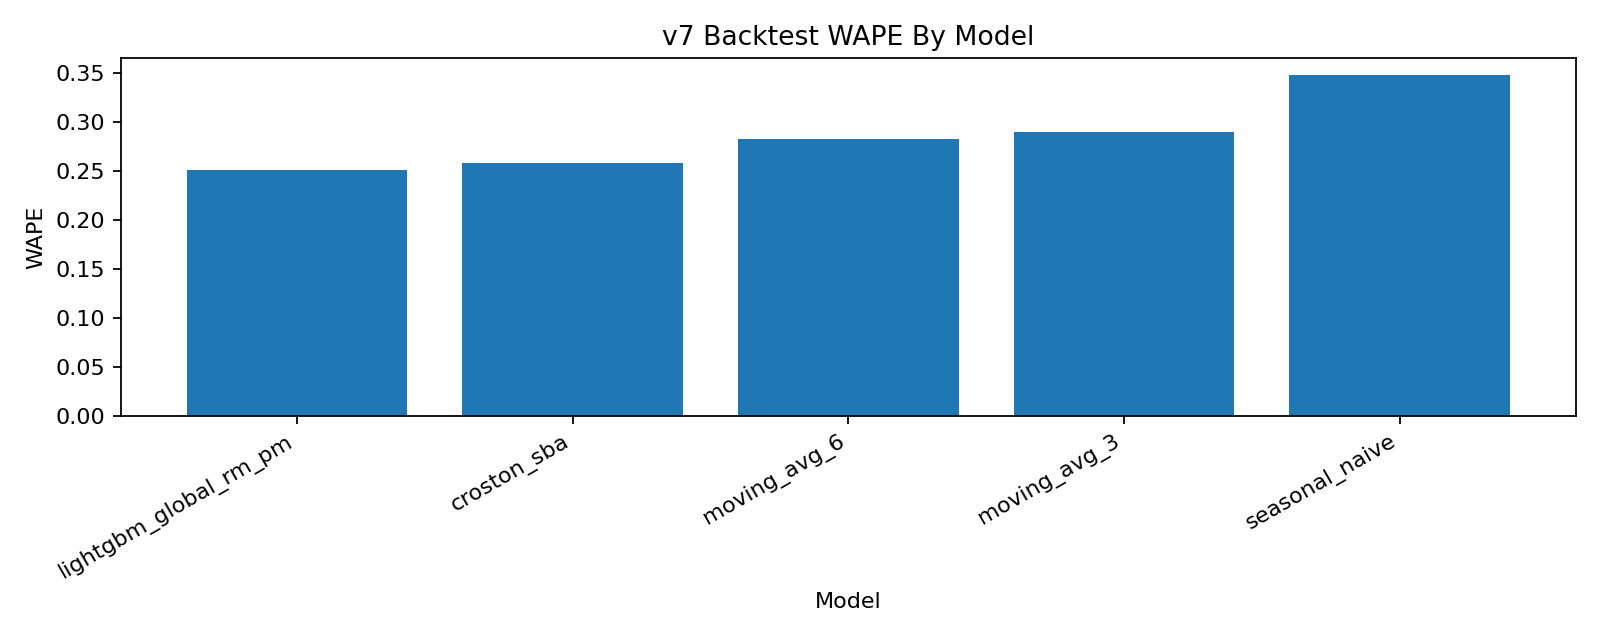

In [4]:
show_plot('model_wape_leaderboard.png')

In [5]:
comparison = load_csv("statistical_comparison.csv")
comparison

,selected_model,candidate_model,paired_rows,mean_abs_error_delta_selected_minus_candidate,selected_better_when_negative,paired_ttest_p_value,test_note
0,lightgbm_global_rm_pm,seasonal_naive,1440,-130.840418,True,0.062840,Paired absolute-error comparison on common mat...
1,lightgbm_global_rm_pm,moving_avg_3,1440,-78.772594,True,0.197160,Paired absolute-error comparison on common mat...
2,lightgbm_global_rm_pm,moving_avg_6,1440,-57.708126,True,0.398828,Paired absolute-error comparison on common mat...
3,lightgbm_global_rm_pm,croston_sba,1440,-15.010878,True,0.798775,Paired absolute-error comparison on common mat...


In [6]:
per_material = load_csv("per_material_metrics.csv")
best = leaderboard.sort_values("WAPE").iloc[0]["model"]
per_material[per_material["model"].eq(best)].sort_values("WAPE", ascending=False).head(30)

,model,material_id,material_code,description,material_type,rows,actual_sum,prediction_sum,WAPE,MAE,RMSE,Bias,under_forecast_rate
288,lightgbm_global_rm_pm,d840bf42-96a8-4870-afc2-f9c1752b6442,101275,HYDROLYZED WHEAT PROTEIN,raw_material,6,0.0,0.405704,4.057045e+08,0.067617,0.071844,4.057045e+08,0.0
289,lightgbm_global_rm_pm,fd6ac4c5-fbfb-4e72-8480-9fdefdebce70,100304,SAVENDRA ROOTS,raw_material,6,0.0,0.218739,2.187390e+08,0.036457,0.039235,2.187390e+08,0.0
290,lightgbm_global_rm_pm,1533fb6c-6669-4677-a91e-4bf065ec0609,100346,WHITE SANDLEWOOD,raw_material,6,0.0,0.218682,2.186824e+08,0.036447,0.037070,2.186824e+08,0.0
291,lightgbm_global_rm_pm,90181ee1-9723-45d3-a204-36f3dda4b1fa,100483,CETRIMIDE B.P,raw_material,6,0.0,0.218682,2.186824e+08,0.036447,0.037070,2.186824e+08,0.0
292,lightgbm_global_rm_pm,c679869f-8737-4d0c-a4ee-65dad4836c21,101369,ORANGE SAI X2L0232,raw_material,6,0.0,0.210720,2.107197e+08,0.035120,0.035446,2.107197e+08,0.0
293,lightgbm_global_rm_pm,dd67a622-a1de-414f-8c90-2d7a47ec4eca,101373,ALMOND SEED,raw_material,6,0.0,0.210720,2.107197e+08,0.035120,0.035446,2.107197e+08,0.0
294,lightgbm_global_rm_pm,6e6bba57-f3bb-4958-87ef-24b9356018a4,101406,WHOLE EGG POWDER,raw_material,6,0.0,0.209706,2.097063e+08,0.034951,0.035144,2.097063e+08,0.0
295,lightgbm_global_rm_pm,23a6b4d0-da52-43d5-8939-019805c0169c,101396,S / WOOD CHIPS,raw_material,6,0.0,0.202816,2.028161e+08,0.033803,0.034002,2.028161e+08,0.0
297,lightgbm_global_rm_pm,51479f4c-c922-4251-8b07-8121e0185fec,101265,ROSE WATER,raw_material,6,0.0,0.199340,1.993401e+08,0.033223,0.033911,1.993401e+08,0.0
298,lightgbm_global_rm_pm,b4d79d99-7c17-4edc-ba7e-3dbb9b7d9d4c,101267,WATER LILLY,raw_material,6,0.0,0.199340,1.993401e+08,0.033223,0.033911,1.993401e+08,0.0
